<a href="https://www.kaggle.com/code/lalit7881/customer-buying-behavior-analysis?scriptVersionId=302790462" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/customer-purchase-behavior-analysis/shopping_trends.csv
/kaggle/input/datasets/algozee/customer-purchase-behavior-analysis/shopping_trends_updated.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/algozee/customer-purchase-behavior-analysis/shopping_trends_updated.csv")

## top 5 values

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## Check Dataset Shape

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (3900, 18)


## Display Column Names

In [5]:
print(df.columns)

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')


## Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

## Check Missing Values

In [7]:
print(df.isnull().sum())

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


## Statistical Summary

In [8]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


## Unique Values in Each Column

In [9]:
print(df['Gender'].value_counts())
print(df['Category'].value_counts())

Gender
Male      2652
Female    1248
Name: count, dtype: int64
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


## Group By Example

In [10]:
category_sales = df.groupby('Category')['Purchase Amount (USD)'].mean()

print(category_sales)

Category
Accessories    59.838710
Clothing       60.025331
Footwear       60.255426
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64


## Sorting Data

In [11]:
df_sorted = df.sort_values(by='Purchase Amount (USD)', ascending=False)

print(df_sorted.head())

      Customer ID  Age Gender Item Purchased   Category  \
1479         1480   48   Male           Coat  Outerwear   
1456         1457   59   Male           Coat  Outerwear   
1591         1592   18   Male          Skirt   Clothing   
2071         2072   69   Male         Jacket  Outerwear   
1421         1422   68   Male          Dress   Clothing   

      Purchase Amount (USD)        Location Size   Color  Season  \
1479                    100      Washington    L   Black  Spring   
1456                    100         Montana    S   Olive  Spring   
1591                    100    South Dakota    L    Gold  Winter   
2071                    100  South Carolina    S  Yellow    Fall   
1421                    100    Pennsylvania    S    Gold  Spring   

      Review Rating Subscription Status Shipping Type Discount Applied  \
1479            4.0                  No      Standard              Yes   
1456            2.7                  No  Store Pickup              Yes   
1591          

## Filtering Data

In [12]:
high_purchase = df[df['Purchase Amount (USD)'] > 80]

print(high_purchase.head())

    Customer ID  Age Gender Item Purchased   Category  Purchase Amount (USD)  \
3             4   21   Male        Sandals   Footwear                     90   
6             7   63   Male          Shirt   Clothing                     85   
8             9   26   Male           Coat  Outerwear                     97   
15           16   64   Male          Skirt   Clothing                     81   
19           20   66   Male          Pants   Clothing                     90   

         Location Size   Color  Season  Review Rating Subscription Status  \
3    Rhode Island    M  Maroon  Spring            3.5                 Yes   
6         Montana    M    Gray    Fall            3.2                 Yes   
8   West Virginia    L  Silver  Summer            2.6                 Yes   
15   Rhode Island    M    Teal  Winter            2.8                 Yes   
19   Rhode Island    M   Green  Summer            3.3                 Yes   

    Shipping Type Discount Applied Promo Code Used  Prev

## Remove Duplicates

In [13]:
df = df.drop_duplicates()

In [14]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [15]:
df.nunique()

Customer ID               3900
Age                         53
Gender                       2
Item Purchased              25
Category                     4
Purchase Amount (USD)       81
Location                    50
Size                         4
Color                       25
Season                       4
Review Rating               26
Subscription Status          2
Shipping Type                6
Discount Applied             2
Promo Code Used              2
Previous Purchases          50
Payment Method               6
Frequency of Purchases       7
dtype: int64

## EDA

## Age Distribution (Histogram)

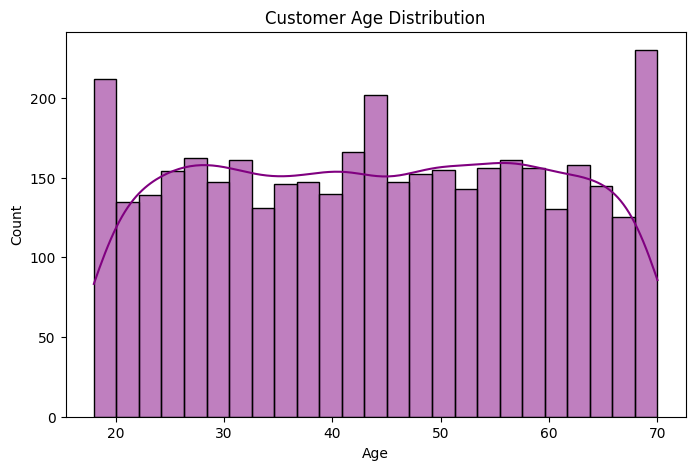

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=25, color='purple', kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

## Gender Distribution (Bar Chart)

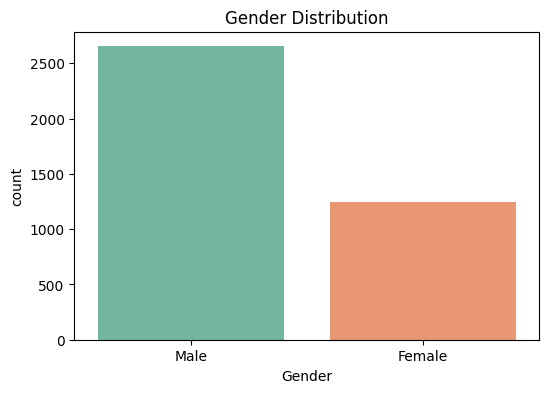

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df, palette='Set2')

plt.title("Gender Distribution")

plt.show()

## Purchase Amount by Category

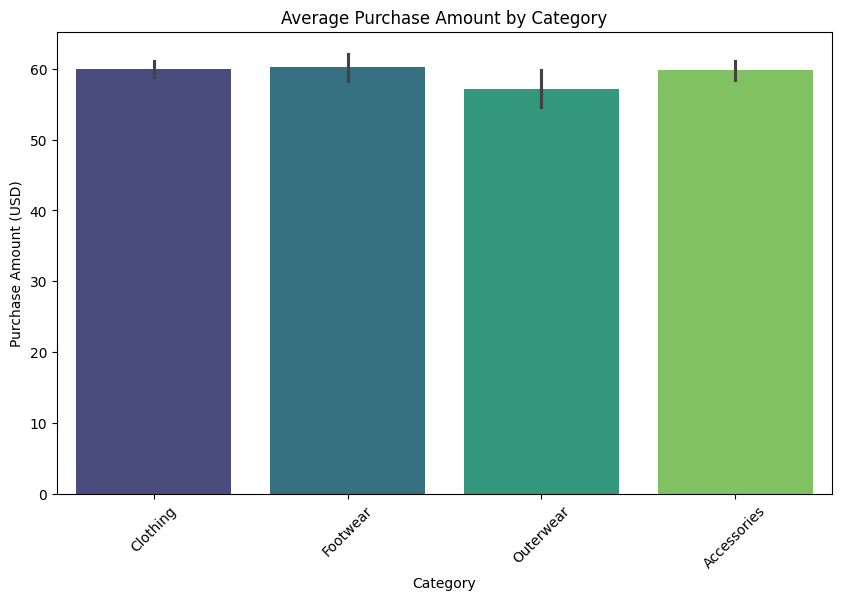

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(x='Category', y='Purchase Amount (USD)', data=df, palette='viridis')

plt.title("Average Purchase Amount by Category")

plt.xticks(rotation=45)

plt.show()

## Season vs Purchase Amount

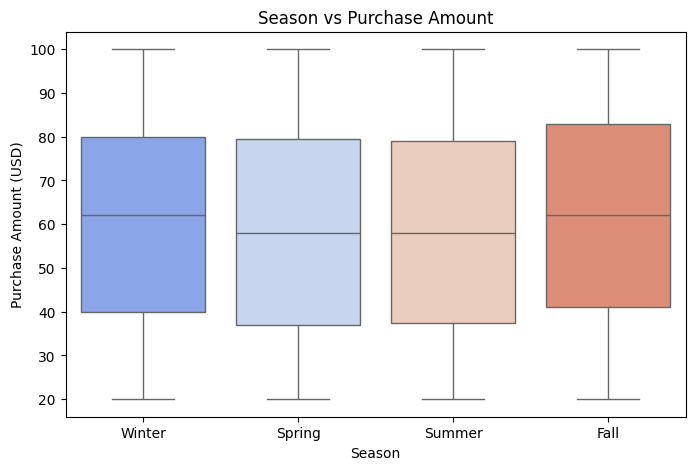

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Season', y='Purchase Amount (USD)', data=df, palette='coolwarm')

plt.title("Season vs Purchase Amount")

plt.show()

## Review Rating Distribution

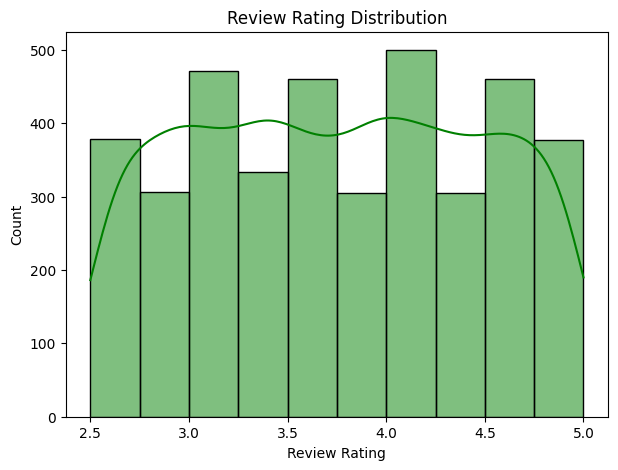

In [20]:
plt.figure(figsize=(7,5))

sns.histplot(df['Review Rating'], bins=10, color='green', kde=True)

plt.title("Review Rating Distribution")

plt.show()

## Location vs Purchase Amount

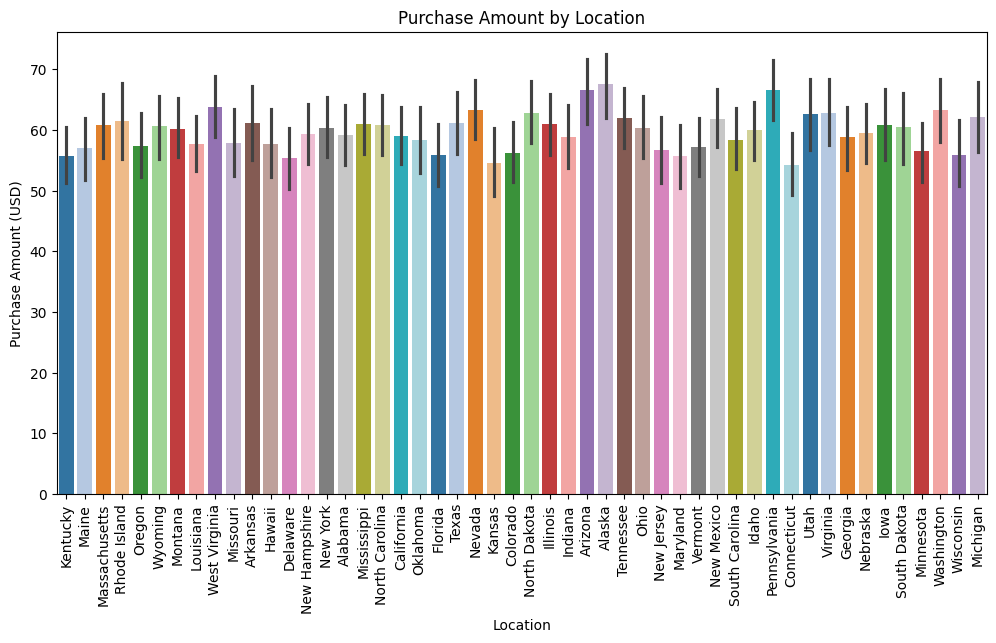

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(x='Location', y='Purchase Amount (USD)', data=df, palette='tab20')

plt.title("Purchase Amount by Location")

plt.xticks(rotation=90)

plt.show()

## Payment Method Distribution

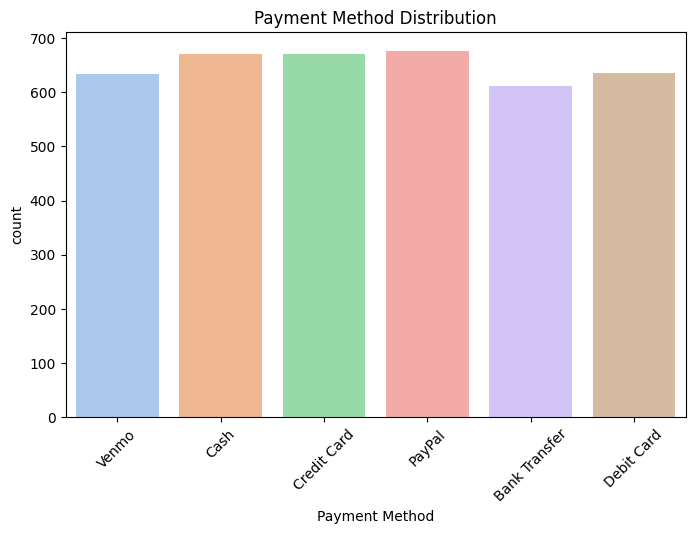

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x='Payment Method', data=df, palette='pastel')

plt.title("Payment Method Distribution")

plt.xticks(rotation=45)

plt.show()

## Discount Applied vs Purchase Amount

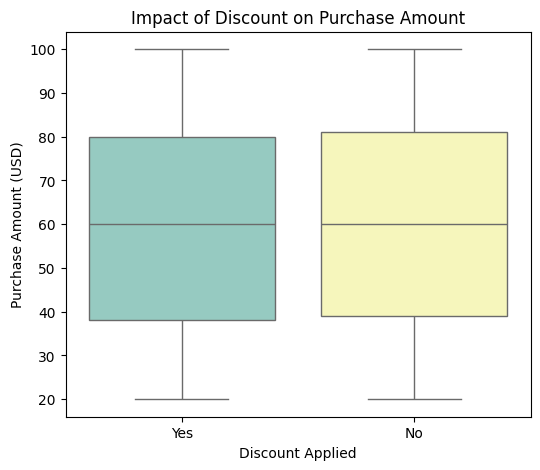

In [23]:
plt.figure(figsize=(6,5))

sns.boxplot(x='Discount Applied', y='Purchase Amount (USD)', data=df, palette='Set3')

plt.title("Impact of Discount on Purchase Amount")

plt.show()

## Promo Code Usage

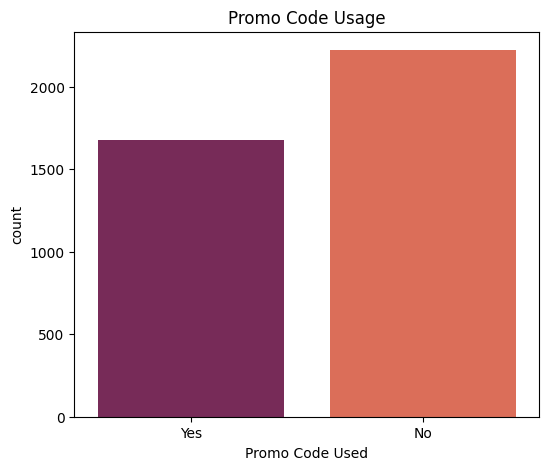

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(x='Promo Code Used', data=df, palette='rocket')

plt.title("Promo Code Usage")

plt.show()

## Shipping Type Distribution

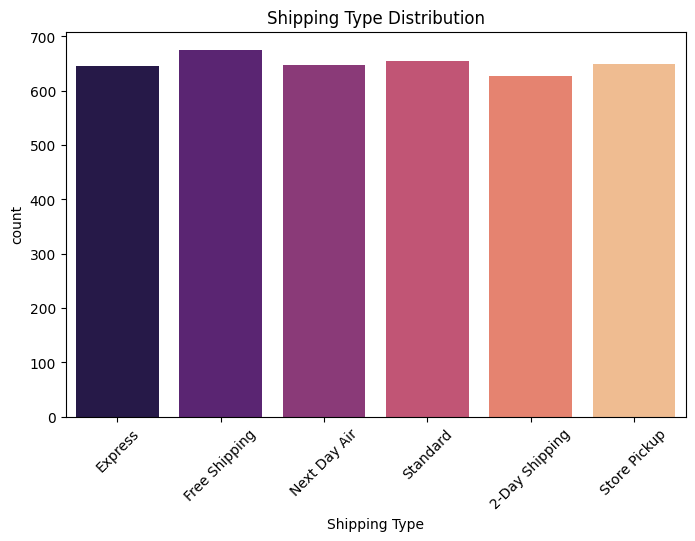

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(x='Shipping Type', data=df, palette='magma')

plt.title("Shipping Type Distribution")

plt.xticks(rotation=45)

plt.show()

## Previous Purchases vs Purchase Amount

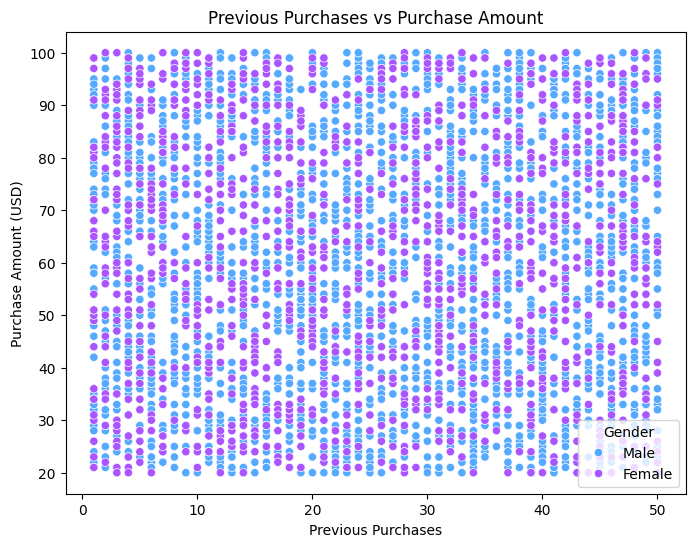

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Previous Purchases',
    y='Purchase Amount (USD)',
    hue='Gender',
    palette='cool',
    data=df
)

plt.title("Previous Purchases vs Purchase Amount")

plt.show()

## Customer Size Preference

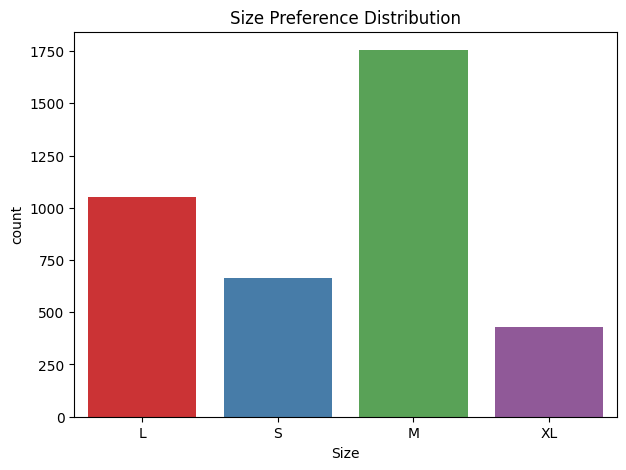

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(x='Size', data=df, palette='Set1')

plt.title("Size Preference Distribution")

plt.show()

## Correlation Heatmap

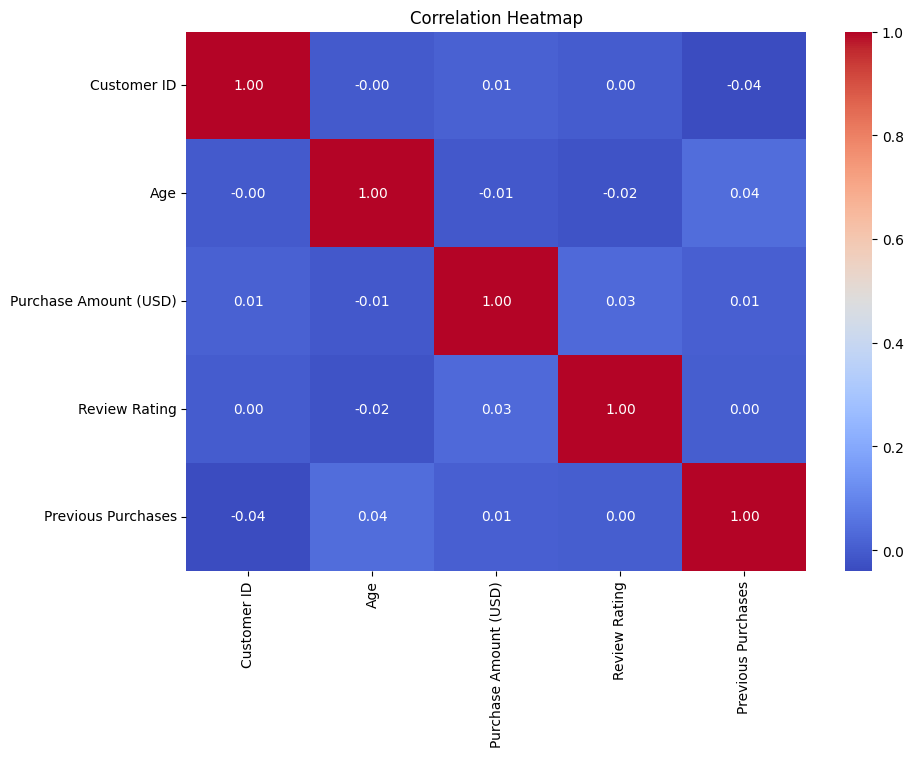

In [28]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Top Purchased Items

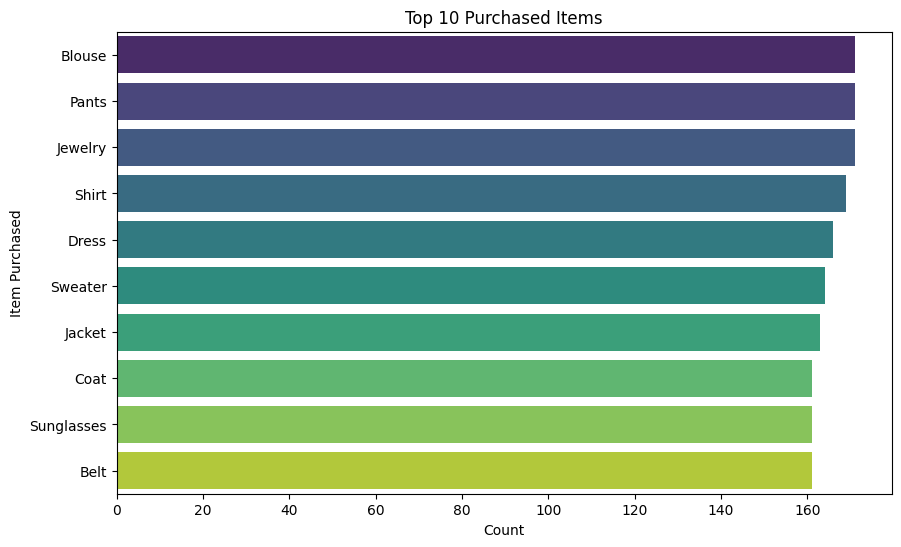

In [29]:
top_items = df['Item Purchased'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_items.values,
    y=top_items.index,
    palette='viridis'
)

plt.title("Top 10 Purchased Items")

plt.xlabel("Count")

plt.show()

## Frequency of Purchases

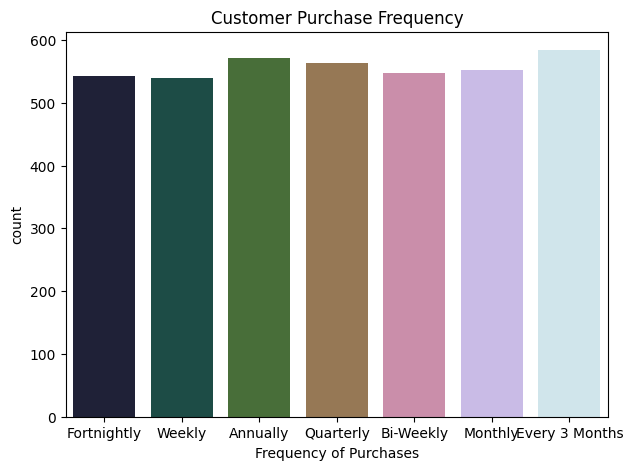

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Frequency of Purchases',
    data=df,
    palette='cubehelix'
)

plt.title("Customer Purchase Frequency")

plt.show()

## Feature engineering

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, confusion_matrix

## Create Target Variable

In [32]:
df['target'] = (df['Purchase Amount (USD)'] > df['Purchase Amount (USD)'].median()).astype(int)

## Select Useful Features

In [33]:
features = [
'Age',
'Review Rating',
'Previous Purchases'
]

X = df[features]
y = df['target']

## Train Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Machine Learning Models

In [36]:
models = {

"Logistic Regression": LogisticRegression(),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(n_estimators=100),

"KNN": KNeighborsClassifier(n_neighbors=5),

"SVM": SVC(),

"Naive Bayes": GaussianNB()

}

## Train Models and Calculate Accuracy

In [37]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.5423076923076923
Decision Tree Accuracy: 0.5205128205128206
Random Forest Accuracy: 0.49743589743589745
KNN Accuracy: 0.5230769230769231
SVM Accuracy: 0.5076923076923077
Naive Bayes Accuracy: 0.5397435897435897


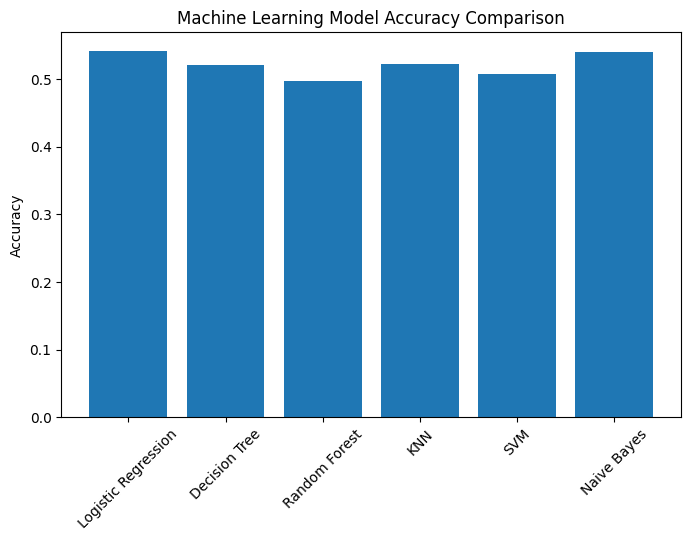

In [38]:
plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.title("Machine Learning Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.show()

In [39]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[209 211]
 [177 183]]


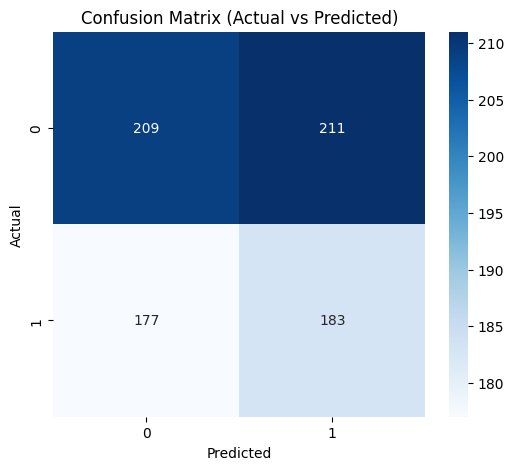

In [40]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (Actual vs Predicted)")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

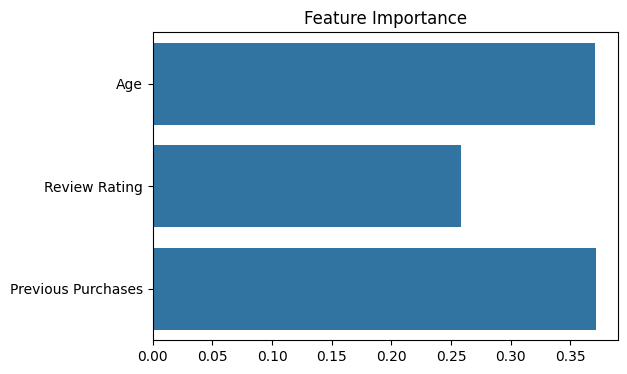

In [41]:
importance = rf.feature_importances_

plt.figure(figsize=(6,4))

sns.barplot(x=importance, y=features)

plt.title("Feature Importance")

plt.show()

## Thank you..pls upvote!!!!!!